In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from onnx import ModelProto
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

In [2]:
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("sahandnamvar/phishing-url-detection-111k-urls-22-features")
os.makedirs("../data", exist_ok=True)

for f in os.listdir(path):
    if f.endswith(".csv"):
        shutil.copy(os.path.join(path, f), f"../data/{f}")
        print(f"✅ Downloaded: ml/data/{f}")

c:\Users\Yanovich\Documents\Projects\PhishVigil\phishvigil\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Downloaded: ml/data/Dataset.csv


In [3]:
df = pd.read_csv("../data/Dataset.csv")

In [4]:
df.head()

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [5]:
print(df["label"].value_counts(normalize=True))

label
0    0.857633
1    0.142367
Name: proportion, dtype: float64


In [6]:
len(df[df["label"] == 1])

16600

In [7]:
X = df.drop(columns=["url", "label", "dom", "tld"])
y = df["label"]

In [8]:
def train_and_score(model, X, y):
    scores = cross_val_score(model, X, y, cv=4)
    min_acc_threshold = 0.9
    if scores.mean() < min_acc_threshold:
        print(
            f"{model.__class__.__name__} accuracy {scores.mean()} (less than {min_acc_threshold}). Stop training"
        )
        return

    print(
        f"{model.__class__.__name__} mean accuracy:\n{scores.mean():.3f} ± {scores.std():.3f}"
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(
        classification_report(
            y_test, y_pred, target_names=["safe", "phishing"], digits=4
        )
    )
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["safe", "phishing"], normalize="true"
    )

    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame(
            {"feature": X.columns, "importance": model.feature_importances_}
        ).sort_values("importance", ascending=False)

        print(importance_df)

    model.fit(X, y)

In [9]:
decision_tree = DecisionTreeClassifier(random_state=42)

DecisionTreeClassifier mean accuracy:
0.962 ± 0.006
              precision    recall  f1-score   support

        safe     0.9829    0.9841    0.9835     19976
    phishing     0.9042    0.8980    0.9011      3344

    accuracy                         0.9717     23320
   macro avg     0.9436    0.9411    0.9423     23320
weighted avg     0.9717    0.9717    0.9717     23320

         feature  importance
15   digit_ratio    0.330962
17      is_https    0.124007
20      path_len    0.100133
1        dom_len    0.094511
19       entropy    0.089961
18     slash_cnt    0.044279
4     subdom_cnt    0.039508
3        tld_len    0.033625
0        url_len    0.028657
11       dot_cnt    0.028145
12      dash_cnt    0.026535
16    spec_ratio    0.019488
5     letter_cnt    0.014299
14  letter_ratio    0.011422
7    special_cnt    0.005765
21     query_len    0.003009
6      digit_cnt    0.001901
8         eq_cnt    0.001765
13     under_cnt    0.001481
9         qm_cnt    0.000363
10       amp

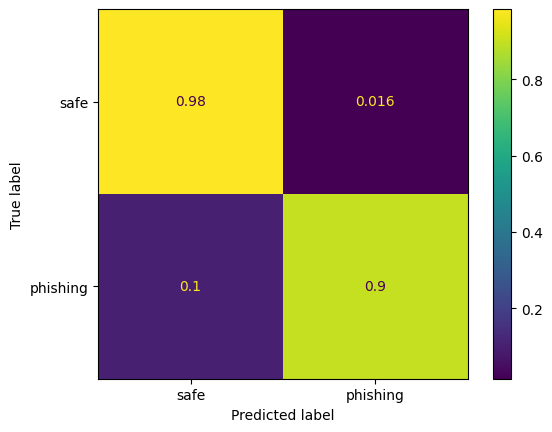

In [10]:
train_and_score(decision_tree, X, y)

In [11]:
hist_boost = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    verbose=0
)

HistGradientBoostingClassifier mean accuracy:
0.974 ± 0.005
              precision    recall  f1-score   support

        safe     0.9844    0.9915    0.9880     19976
    phishing     0.9469    0.9064    0.9262      3344

    accuracy                         0.9793     23320
   macro avg     0.9657    0.9489    0.9571     23320
weighted avg     0.9791    0.9793    0.9791     23320



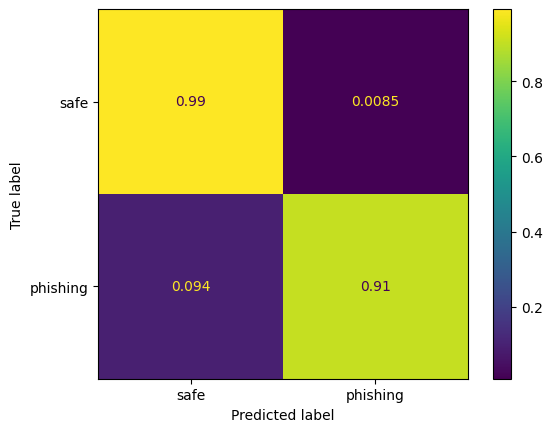

In [12]:
train_and_score(hist_boost, X, y)

In [16]:
initial_type = [('float_input', FloatTensorType([None, X.shape[1]]))]
onx = convert_sklearn(decision_tree, initial_types=initial_type, target_opset=14)

In [ ]:
assert isinstance(onx, ModelProto)

os.makedirs("../output", exist_ok=True)
with open("../output/phish_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print(f"✅ Экспортировано: phish_model.onnx ({onx.ByteSize() / 1024:.1f} KB)")

✅ Экспортировано: phish_model.onnx (244.8 KB)
